In [1]:
!pip install gensim

In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split ,cross_val_score, StratifiedKFold

# --- ML Algorithms ---
from sklearn.naive_bayes      import MultinomialNB
from sklearn.linear_model     import LogisticRegression, SGDClassifier
from sklearn.svm              import LinearSVC
from sklearn.ensemble         import RandomForestClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Yashwanth Boya\OneDrive\Documents\Desktop\PBL\New folder\archive (2) (1)\sentiment_data.csv", index_col=0)

df = df.sample(10000)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 2)

First 5 rows:


,Comment,Sentiment
46753,NaN,1
35391,like new profile pic cute,2
97452,budget return protectionism panagariya sounds ...,2
21148,meeeaaannn people make mistakes ok lol,0
108645,hey modifobia said modis agenda election growt...,0


In [4]:
# --- Check for nulls ---
print("Null values per column:")
print(df.isnull().sum())

# --- Drop rows with missing comments ---
df.dropna(subset=['Comment'], inplace=True)
df['Comment'] = df['Comment'].astype(str)

print(f"\nClean dataset size: {len(df):,} rows")

Null values per column:
Comment      13
Sentiment     0
dtype: int64

Clean dataset size: 9,987 rows


Class Distribution:
  0 (Negative):   2,319  (23.2%)
  1 (Neutral):   3,416  (34.2%)
  2 (Positive):   4,252  (42.6%)


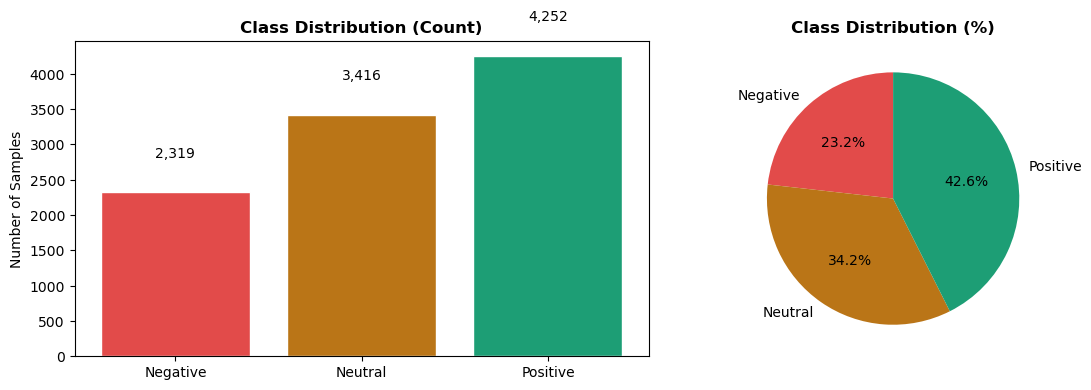


Comment Word Count Statistics:
count    9987.0
mean       13.2
std        11.8
min         1.0
25%         7.0
50%        11.0
75%        18.0
max       742.0
Name: comment_length, dtype: float64


In [5]:
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# Class distribution
class_counts = df['Sentiment'].value_counts().sort_index()
print("Class Distribution:")
for label, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {label} ({label_names[label]}): {count:>7,}  ({pct:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#E24B4A', '#BA7517', '#1D9E75']
axes[0].bar([label_names[i] for i in range(3)], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values,
            labels=[label_names[i] for i in range(3)],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()

# Comment length analysis
df['comment_length'] = df['Comment'].apply(lambda x: len(x.split()))
print("\nComment Word Count Statistics:")
print(df['comment_length'].describe().round(1))

In [6]:
X_raw = df['Comment'].values   # Raw text
y     = df['Sentiment'].values  # Labels (0, 1, 2)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size    = 0.2,        # 80% train, 20% test
    random_state = 42,         # reproducible split
    stratify     = y           # maintain class ratios in both splits
)

print(f"Training samples : {len(X_train_raw):>7,}")
print(f"Test samples     : {len(X_test_raw):>7,}")

Training samples :   7,989
Test samples     :   1,998


In [7]:
# =============================================================
# STEP 1: Contraction Expansion
# -------------------------------------------------------------
# WHY: "don't" and "do not" should be treated the same.
#      BOW treats them as completely different words otherwise.
# HOW: Simple dictionary lookup and replace.
# NOTE: Must happen BEFORE punctuation removal!
# =============================================================

CONTRACTIONS = {
    "don't":"do not", "doesn't":"does not", "didn't":"did not",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "haven't":"have not", "hasn't":"has not",
    "hadn't":"had not", "won't":"will not", "wouldn't":"would not",
    "can't":"cannot", "couldn't":"could not", "shouldn't":"should not",
    "mustn't":"must not", "needn't":"need not", "i'm":"i am",
    "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "it'd":"it would", "it'll":"it will",
    "that's":"that is", "that'd":"that would", "that'll":"that will",
    "they're":"they are", "they've":"they have", "they'll":"they will",
    "they'd":"they would", "we're":"we are", "we've":"we have",
    "we'll":"we will", "we'd":"we would", "you're":"you are",
    "you've":"you have", "you'll":"you will", "you'd":"you would",
    "he's":"he is", "he'd":"he would", "he'll":"he will",
    "she's":"she is", "she'd":"she would", "she'll":"she will",
    "there's":"there is", "there're":"there are",
    "who's":"who is", "who'd":"who would", "who'll":"who will",
    "what's":"what is", "what're":"what are", "what'll":"what will",
    "let's":"let us", "y'all":"you all", "gonna":"going to",
    "wanna":"want to", "gotta":"got to", "kinda":"kind of",
    "sorta":"sort of", "dunno":"do not know", "ain't":"is not",
    "'ve":" have", "'re":" are", "'ll":" will", "'d":" would"
}

def expand_contractions(text):
    # Sort by length descending so longer contractions match first
    for contraction, expansion in sorted(CONTRACTIONS.items(),
                                          key=lambda x: len(x[0]), reverse=True):
        text = text.replace(contraction, expansion)
    return text


# =============================================================
# STEP 2: Remove URLs
# -------------------------------------------------------------
# WHY: URLs like "https://youtube.com" add no sentiment signal.
# HOW: Regex pattern matches http/https/www links.
# =============================================================

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)


# =============================================================
# STEP 3: Remove Non-ASCII Characters
# -------------------------------------------------------------
# WHY: Our data has Malayalam script (Kerala language), Chinese,
#      Arabic etc. BOW on English models can't use these.
#      Example: "liquid nitrogen ഇതുവരെ തീർന്നില്ലേ" → "liquid nitrogen"
# HOW: Keep only characters in ASCII range (0-127).
# NOTE: If your task NEEDS multilingual support, skip this step
#       and use a multilingual model instead.
# =============================================================

def remove_non_ascii(text):
    return text.encode('ascii', errors='ignore').decode('ascii')


# =============================================================
# STEP 4: Remove Punctuation & Special Characters
# -------------------------------------------------------------
# WHY: Characters like !@#$%^&*()"'…— carry minimal ML signal
#      for BOW. They fragment tokens and pollute vocabulary.
# HOW: Keep only letters and spaces using regex.
# NOTE: Some NLP tasks DO want punctuation (e.g., !!! shows emotion).
#       For BOW classification, removing is usually better.
# =============================================================

def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)


# =============================================================
# STEP 5: Normalise Repeated Characters
# -------------------------------------------------------------
# WHY: "reallly" and "really" should be the same word.
#      "qualiity" → "quality". Typos and emphasis cause vocabulary
#      explosion and sparse, unhelpful features.
# HOW: Collapse any character repeated 3+ times to just 2.
#      We keep 2 (not 1) because "oo" in "good" is valid.
# =============================================================

def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


# =============================================================
# STEP 6: Lowercase
# -------------------------------------------------------------
# WHY: "Apple", "apple", "APPLE" should all map to the same token.
#      Without this, BOW treats them as 3 different features.
# NOTE: We do this AFTER contraction expansion so the lookup
#       table works correctly on original casing.
# =============================================================

def to_lowercase(text):
    return text.lower()


# =============================================================
# STEP 7: Remove Extra Whitespace
# -------------------------------------------------------------
# WHY: Cleaning steps above leave behind multiple spaces.
#      Tokeniser splits on whitespace, so clean it up.
# =============================================================

def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()


# =============================================================
# MASTER CLEANING FUNCTION
# Apply all steps in the correct order.
# =============================================================

def clean_text(text):
    text = str(text)                      # ensure string
    text = to_lowercase(text)             # lowercase first for contraction lookup
    text = expand_contractions(text)      # don't → do not  (BEFORE punctuation removal)
    text = remove_urls(text)              # remove http links
    text = remove_non_ascii(text)         # remove Malayalam, Chinese, etc.
    text = remove_punctuation(text)       # remove !@#"'… etc.
    text = normalize_repeated_chars(text) # reallly → really
    text = remove_extra_whitespace(text)  # squeeze multiple spaces
    return text


print("All cleaning functions defined!")
print("\nFunction order:")
print("  1. to_lowercase")
print("  2. expand_contractions  ← must be before punctuation removal")
print("  3. remove_urls")
print("  4. remove_non_ascii")
print("  5. remove_punctuation")
print("  6. normalize_repeated_chars")
print("  7. remove_extra_whitespace")

All cleaning functions defined!

Function order:
  1. to_lowercase
  2. expand_contractions  ← must be before punctuation removal
  3. remove_urls
  4. remove_non_ascii
  5. remove_punctuation
  6. normalize_repeated_chars
  7. remove_extra_whitespace


In [8]:
# =============================================================
# Apply cleaning to Train and Test separately
# IMPORTANT: Same function applied to both — no fitting here.
# Rule-based cleaning (regex) does NOT learn from data,
# so it's safe to apply identically to train and test.
# =============================================================

print("Cleaning training data...", end=' ')
t0 = time.time()
X_train_clean = np.array([clean_text(t) for t in X_train_raw])
print(f"done ({time.time()-t0:.1f}s)")

print("Cleaning test data...",     end=' ')
t0 = time.time()
X_test_clean  = np.array([clean_text(t) for t in X_test_raw])
print(f"done ({time.time()-t0:.1f}s)")


# =============================================================
# STEP 8: Remove Very Short Comments
# -------------------------------------------------------------
# WHY: After cleaning, some comments become 1-2 words — not
#      enough signal for classification. Drop them.
# THRESHOLD: 3 words minimum. Adjust based on your data.
# NOTE: Only filter TRAINING data. Keep all test samples for
#       fair evaluation.
# =============================================================

MIN_WORDS = 3

train_lengths = np.array([len(t.split()) for t in X_train_clean])
train_mask    = train_lengths >= MIN_WORDS

removed = (~train_mask).sum()
X_train_clean = X_train_clean[train_mask]
y_train       = y_train[train_mask]

print(f"\nShort comment filter (< {MIN_WORDS} words):")
print(f"  Removed from train : {removed:,}")
print(f"  Final train size   : {len(X_train_clean):,}")
print(f"  Test size          : {len(X_test_clean):,}  (unchanged — never filter test)")


# =============================================================
# Compare vocabulary size: raw vs cleaned
# =============================================================

raw_vocab   = set(' '.join(X_train_raw).split())
clean_vocab = set(' '.join(X_train_clean).split())

print(f"\nVocabulary size BEFORE cleaning : {len(raw_vocab):,} unique tokens")
print(f"Vocabulary size AFTER  cleaning : {len(clean_vocab):,} unique tokens")
print(f"Reduction: {len(raw_vocab) - len(clean_vocab):,} noisy tokens removed")

Cleaning training data... done (0.3s)
Cleaning test data... done (0.1s)

Short comment filter (< 3 words):
  Removed from train : 343
  Final train size   : 7,646
  Test size          : 1,998  (unchanged — never filter test)

Vocabulary size BEFORE cleaning : 19,251 unique tokens
Vocabulary size AFTER  cleaning : 18,491 unique tokens
Reduction: 760 noisy tokens removed


In [9]:
def tokenize(text):
    return text.split()

X_train_tokens = [tokenize(text) for text in X_train_clean]
X_test_tokens  = [tokenize(text) for text in X_test_clean]

In [10]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences   = X_train_tokens,
    vector_size = 100,      # similar to max_features idea but dense
    window      = 5,
    min_count   = 2,        # similar to min_df
    workers     = 4
)

In [11]:
import numpy as np

def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

In [12]:
X_train_w2v = np.array([
    sentence_vector(tokens, w2v_model) 
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    sentence_vector(tokens, w2v_model) 
    for tokens in X_test_tokens
])

In [13]:
print(f"Train Word2Vec matrix : {X_train_w2v.shape}")
print(f"Test  Word2Vec matrix : {X_test_w2v.shape}")

print(f"Vector size (embedding dim): {w2v_model.vector_size}")

print("\nSample word vectors:")
sample_words = list(w2v_model.wv.index_to_key)[:10]

for word in sample_words:
    print(f"{word} → {w2v_model.wv[word][:5]}...")  # first 5 values

Train Word2Vec matrix : (7646, 100)
Test  Word2Vec matrix : (1998, 100)
Vector size (embedding dim): 100

Sample word vectors:
modi → [-0.5301265   0.9176429   0.5991816   0.10810688  0.10739715]...
india → [-0.5333374   0.8942874   0.5783256   0.09919352  0.14745149]...
like → [-0.5228146   0.9298804   0.56634885  0.07175459  0.15808968]...
people → [-0.49142197  0.8515757   0.5213049   0.06998546  0.13907708]...
one → [-0.5121724   0.8840611   0.5408602   0.06470823  0.15009306]...
bjp → [-0.53653955  0.9114115   0.5690502   0.07982148  0.13272224]...
dont → [-0.48142904  0.8616267   0.5322455   0.06628092  0.13671917]...
narendra → [-0.40877986  0.73625493  0.5117152   0.10463046  0.09954579]...
congress → [-0.5532956   0.9307761   0.57934785  0.10827411  0.14961953]...
time → [-0.48596966  0.8245191   0.5076495   0.07760324  0.13384691]...


In [14]:
# =============================================================
# ALGORITHM 1: Multinomial Naive Bayes
# HOW IT WORKS: Uses probability. P(Positive | word) based on
#               how often each word appears in each class.
# WHEN TO USE : First model to try for text. Fast, needs less
#               data, works well with sparse BOW.
# WEAKNESS    : Assumes words are independent (often not true).
#
# KEY PARAMS:
#   alpha : Laplace smoothing. Avoids zero probability for
#           unseen words. Default 1.0. Try 0.1 or 0.5 if
#           accuracy is low — more smoothing = simpler model.
# =============================================================
nb_model = MultinomialNB(alpha=1.0)


# =============================================================
# ALGORITHM 2: Logistic Regression
# HOW IT WORKS: Finds a linear decision boundary. Gives
#               probability estimates per class (0.0 to 1.0).
# WHEN TO USE : When you need probability scores, not just
#               labels. Great all-round text classifier.
#
# KEY PARAMS:
#   C        : Inverse regularisation strength.
#              Low  C = simpler model (prevents overfitting).
#              High C = fits data tightly (can overfit).
#              Try: 0.01, 0.1, 1.0, 10.0
#   max_iter : Increase if you see ConvergenceWarning.
#   solver   : 'lbfgs' is best for multiclass problems.
# =============================================================
lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 1000,
    solver       = 'lbfgs',
    multi_class  = 'auto',
    random_state = 42
)


# =============================================================
# ALGORITHM 3: Linear SVM
# HOW IT WORKS: Finds the widest possible margin between
#               classes. Gold standard for text classification.
# WHEN TO USE : When accuracy is the top priority.
#               High-dimensional sparse data (like BOW).
# WEAKNESS    : No probability output.
#
# KEY PARAMS:
#   C        : Margin vs misclassification tradeoff.
#              Same logic as Logistic Regression's C.
#   max_iter : Increase if model issues convergence warning.
# =============================================================
svm_model = LinearSVC(
    C        = 1.0,
    max_iter = 2000
)


# =============================================================
# ALGORITHM 4: SGD Classifier
# HOW IT WORKS: Online learning — one sample at a time using
#               gradient descent. Very memory efficient.
# WHEN TO USE : Millions of docs. Data too large for RAM.
#               Streaming/real-time incoming data.
#
# KEY PARAMS:
#   loss     : 'modified_huber' gives probabilities + noise robustness.
#              'hinge' = mimics Linear SVM. 'log_loss' = mimics LR.
#   alpha    : Regularisation. Increase if model overfits.
#   max_iter : Epochs (passes over full training data).
# =============================================================
sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 1e-4,
    max_iter     = 100,
    random_state = 42
)


# =============================================================
# ALGORITHM 5: Random Forest
# HOW IT WORKS: Many decision trees on random data subsets.
#               Each tree votes — majority wins.
# WHEN TO USE : Mixed features (text + numeric). Non-linear
#               patterns. Feature importance analysis.
# WEAKNESS    : Slow on high-dim sparse BOW. Memory heavy.
#
# KEY PARAMS:
#   n_estimators     : Number of trees. More = better (to a point).
#   max_depth        : None = grow until pure. Limit to avoid overfit.
#   min_samples_leaf : Higher = smoother, less overfit.
#   n_jobs           : -1 = use all CPU cores.
# =============================================================
rf_model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = None,
    min_samples_leaf = 1,
    random_state     = 42,
    n_jobs           = -1
)

print(" All 5 models defined!")

 All 5 models defined!


In [15]:
models = {
    'Naive Bayes'         : nb_model,
    'Logistic Regression' : lr_model,
    'Linear SVM'          : svm_model,
    'SGD Classifier'      : sgd_model,
    'Random Forest'       : rf_model
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print(f"{'Model':<25} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7}  {'Mean':>7} {'Std':>7}")
print("-" * 78)

for name, model in models.items():
    t0     = time.time()
    scores = cross_val_score(
        model, X_train_w2v, y_train,
        cv      = skf,
        scoring = 'accuracy',
        n_jobs  = -1
    )
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f"{name:<25} {scores[0]:>7.4f} {scores[1]:>7.4f} {scores[2]:>7.4f} {scores[3]:>7.4f} {scores[4]:>7.4f}  {scores.mean():>7.4f} {scores.std():>7.4f}  [{elapsed:.1f}s]")

Model                          F1      F2      F3      F4      F5     Mean     Std
------------------------------------------------------------------------------


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Yashwanth Boya\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Yashwanth Boya\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Yashwanth Boya\anaconda3\Lib\site-packages\sklearn\naive_bayes.py", line 762, in fit
    self._count(X, Y)
    ~~~~~~~~~~~^^^^^^
  File "C:\Users\Yashwanth Boya\anaconda3\Lib\site-packages\sklearn\naive_bayes.py", line 889, in _count
    check_non_negat

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

# optional: auto colors (avoids mismatch error)
colors = plt.cm.tab10.colors[:len(names)]

bars = ax.barh(names, means, xerr=stds,
               color=colors, edgecolor='white',
               capsize=5, alpha=0.9)

for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{mean:.4f} ± {std:.4f}',
            va='center', fontsize=10)

# dynamic limit (better for W2V results)
ax.set_xlim(min(means) - 0.05, 1.05)

ax.set_xlabel('CV Accuracy', fontsize=11)
ax.set_title('5-Fold Cross Validation (Word2Vec Features)', fontweight='bold')

plt.tight_layout()
plt.show()

best_cv = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"\nBest CV model: {best_cv} (mean = {cv_results[best_cv].mean():.4f})")

In [ ]:
trained_models = {}
train_times    = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    t0 = time.perf_counter()
    model.fit(X_train_w2v, y_train)
    t1 = time.perf_counter()
    trained_models[name] = model
    train_times[name]    = t1 - t0
    print(f"✓  ({t1-t0:.2f}s)")

print(" All models trained and saved in `trained_models` dict")
print("   Access any model:  trained_models['Linear SVM']")

In [ ]:
timing_results = {}
N_RUNS = 50

print(f"Benchmarking on {X_test_w2v.shape[0]:,} test samples × {N_RUNS} runs...\n")
print(f"{'Model':<25} {'Avg (ms)':>10} {'Per doc (µs)':>14} {'% of slowest':>14}")
print("-" * 68)

for name, model in trained_models.items():
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        _  = model.predict(X_test_w2v)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    avg_ms  = np.mean(times) * 1000
    per_doc = np.mean(times) / X_test_w2v.shape[0] * 1_000_000

    timing_results[name] = {'avg_ms': avg_ms, 'per_doc': per_doc}

slowest_ms = max(timing_results[n]['avg_ms'] for n in timing_results)

for name, res in timing_results.items():
    pct = res['avg_ms'] / slowest_ms * 100
    print(f"{name:<25} {res['avg_ms']:>10.2f} {res['per_doc']:>14.2f} {pct:>14.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names_t  = list(timing_results.keys())
avg_ms   = [timing_results[n]['avg_ms']  for n in names_t]
pcts     = [t / slowest_ms * 100 for t in avg_ms]
colors   = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30', '#E24B4A']

axes[0].barh(names_t, avg_ms, color=colors, edgecolor='white', alpha=0.9)
for i, v in enumerate(avg_ms):
    axes[0].text(v + 0.5, i, f'{v:.1f} ms', va='center', fontsize=10)
axes[0].set_xlabel('Average inference time (ms)')
axes[0].set_title('Total Test Set Inference Time', fontweight='bold')

axes[1].barh(names_t, pcts, color=colors, edgecolor='white', alpha=0.9)
axes[1].axvline(x=100, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(pcts):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_xlabel('% of slowest model')
axes[1].set_title('Relative Speed (lower = faster)', fontweight='bold')

plt.tight_layout()
plt.show()

fastest      = min(timing_results, key=lambda n: timing_results[n]['avg_ms'])
slowest_name = max(timing_results, key=lambda n: timing_results[n]['avg_ms'])
speedup = timing_results[slowest_name]['avg_ms'] / timing_results[fastest]['avg_ms']
print(f"\n Fastest: {fastest}")
print(f" Slowest: {slowest_name}")
print(f"   {fastest} is {speedup:.0f}× faster than {slowest_name}")

In [ ]:
target_names = ['Negative', 'Neutral', 'Positive']
test_results = {}

for name, model in trained_models.items():
    preds = model.predict(X_test_w2v)
    acc   = accuracy_score(y_test, preds)
    test_results[name] = {'acc': acc, 'preds': preds}

    print(f"\n{'='*60}")
    print(f" {name}  |  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print('='*60)
    print(classification_report(y_test, preds, target_names=target_names))

In [ ]:
best_test_model = max(test_results, key=lambda n: test_results[n]['acc'])
best_preds      = test_results[best_test_model]['preds']

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_test_model}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHow to read this:")
print("  Rows = Actual class    Columns = Predicted class")
print("  Diagonal = correct predictions")
print("  Off-diagonal = errors (what got confused with what)")

In [ ]:
summary_data = []
for name in trained_models:
    summary_data.append({
        'Model'           : name,
        'CV Mean Acc'     : f"{cv_results[name].mean():.4f}",
        'CV Std'          : f"{cv_results[name].std():.4f}",
        'Test Accuracy'   : f"{test_results[name]['acc']:.4f}",
        'Train Time (s)'  : f"{train_times[name]:.2f}s",
        'Infer Time (ms)' : f"{timing_results[name]['avg_ms']:.1f}ms",
        'Per Doc (µs)'    : f"{timing_results[name]['per_doc']:.1f}µs"
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print("\n📋 FINAL COMPARISON TABLE")
print("=" * 85)
print(summary_df.to_string())
print("=" * 85)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names_all = list(trained_models.keys())
test_accs = [test_results[n]['acc'] for n in names_all]
infer_ms  = [timing_results[n]['avg_ms'] for n in names_all]
colors    = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30', '#E24B4A']

bars = axes[0].bar(names_all, test_accs, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Set Accuracy by Model', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.003,
                 f'{v:.3f}', ha='center', fontsize=10)

bars2 = axes[1].bar(names_all, infer_ms, color=colors, edgecolor='white', alpha=0.9)
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time (lower = faster)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, infer_ms):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.0f}ms', ha='center', fontsize=10)

plt.tight_layout()
plt.show()